# 01 — Build the global 0.5° grid

Creates the base `(lat, lon)` grid used by every variable notebook and stores a Natural Earth land mask so downstream notebooks can skip pure-ocean cells. The mask uses fractional coverage on the 1:10m polygons, so coastal cells with only partial land and cells containing small islands are retained.

In [24]:
import numpy as np
import xarray as xr
import regionmask

from common import PROCESSED_DIR

## Mesh

Cell centers at 0.5° spacing: 720 lon × 719 lat = 517 680 cells globally. Each cell is around 50km^2

In [25]:
RES = 0.5
lon = np.arange(-180 + RES / 2, 180, RES)
lat = np.arange(-90 + RES / 2, 90, RES)
print(f'{lon.size} lon × {lat.size} lat = {lon.size * lat.size:,} cells')

720 lon × 360 lat = 259,200 cells


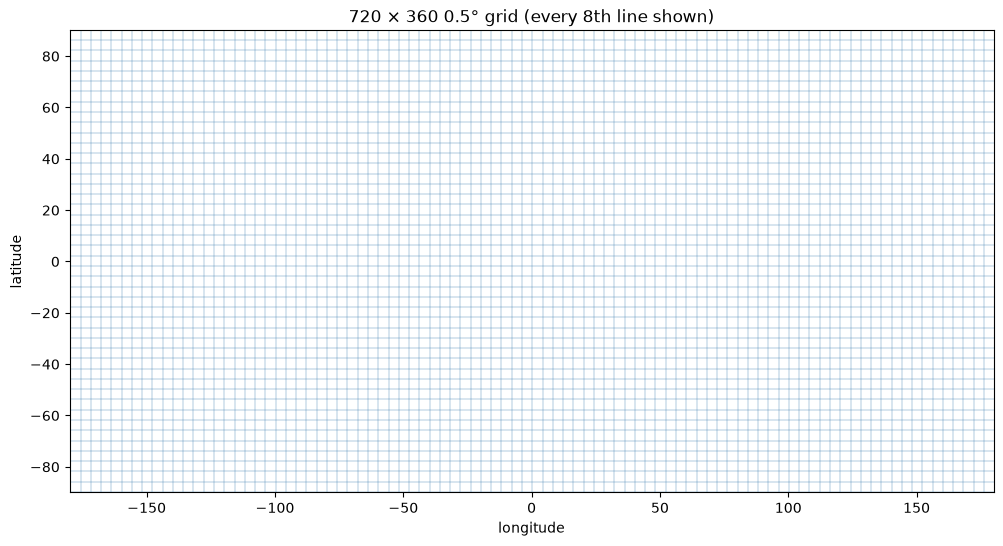

In [26]:
import matplotlib.pyplot as plt

step = 8  # show every Nth line so cells stay visible at global scale
fig, ax = plt.subplots(figsize=(12, 6))
for x in lon[::step]:
    ax.axvline(x, color='steelblue', lw=0.3)
for y in lat[::step]:
    ax.axhline(y, color='steelblue', lw=0.3)
ax.set_xlim(-180, 180)
ax.set_ylim(-90, 90)
ax.set_aspect('equal')
ax.set_xlabel('longitude')
ax.set_ylabel('latitude')
ax.set_title(f'{lon.size} × {lat.size} 0.5° grid (every {step}th line shown)')
plt.show()

## Land mask

For each 0.5° cell we compute the fraction covered by Natural Earth **1:10m** land polygons via `mask_3D_frac_approx` (which subsamples each cell), then subtract the fraction covered by Antarctica (out of scope for the atlas). Any cell with a non-zero residual land fraction is kept — this includes coastal cells with only partial land coverage and cells whose centers sit in the ocean but which contain small islands. Bumping from `land_110` to `land_10` also brings in island geometry the coarse dataset omits entirely.

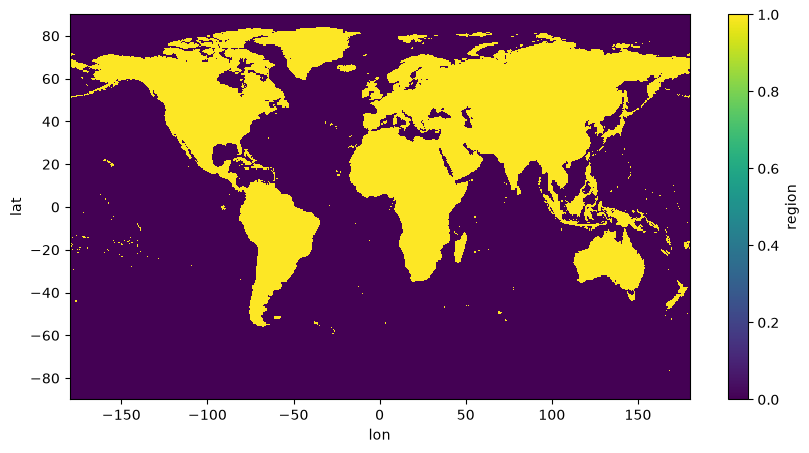

In [27]:
land = regionmask.defined_regions.natural_earth_v5_0_0.land_10
land_frac = land.mask_3D_frac_approx(lon, lat).isel(region=0)

countries = regionmask.defined_regions.natural_earth_v5_0_0.countries_10
antarctica_idx = countries.map_keys('Antarctica')
antarctica_only = countries[[antarctica_idx]]
antarctica_frac = antarctica_only.mask_3D_frac_approx(lon, lat).isel(region=0)

is_land = ((land_frac - antarctica_frac).clip(min=0) > 0).astype('int8')
is_land.plot(figsize=(10, 5))

## Save

In [28]:
from pathlib import Path

grid = xr.Dataset(
    {'is_land': is_land},
    attrs={'resolution_deg': RES, 'source': 'Natural Earth 110m via regionmask'},
)

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
out = PROCESSED_DIR / 'grid.nc'

if Path(out).exists():
    Path(out).unlink()
    
grid.to_netcdf(out)
print(f'wrote {out}')

wrote /Users/lutz/Documents/alfatraining/projects/data-science-notebooks/data/world-livable-atlas/processed/grid.nc
